# Training application model

In [13]:
import pandas as pd
import numpy as np

from pathlib import Path
from anomaly_detection.parser.data_parsers import parse_system
from anomaly_detection.transformers import system_transformer

In [14]:
# Path to the data
project_folder = Path.cwd().parent

output_path = project_folder / "data/training/system"

model_path = project_folder / "src/anomaly_detection/models"

transformer_path = project_folder / "src/anomaly_detection/storage/transformers"

system_evtx_path = project_folder / "data/raw/93_syslog.evtx"

system_evtx_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/raw/93_syslog.evtx')

# Data preparation

In [15]:
system_training_records = parse_system(system_evtx_path)

system_training_records[0]

{'EventRecordID': 210478,
 'timestamp': {'second_sin': np.float64(-0.9781476007338056),
  'month_sin': np.float64(1.0),
  'deltatime': Timedelta('0 days 00:02:19.046309'),
  'hour_cos': np.float64(0.5000000000000001),
  'day_cos': np.float64(-0.9009688679024191),
  'second_cos': np.float64(0.20791169081775943),
  'hour_sin': np.float64(0.8660254037844386),
  'day_sin': np.float64(-0.433883739117558),
  'month_cos': np.float64(6.123233995736766e-17),
  'minute_sin': np.float64(-0.20791169081775898),
  'minute_cos': np.float64(0.9781476007338057)},
 'profile': {'previous_event_id': 7036,
  'event_id': 7036,
  'correlation_activity_id': None,
  'event_id_frequency': np.float64(0.9060706937218755),
  'version': 0,
  'event_record_id': 210478,
  'execution_thread_id': 5368},
 'data': {'session_id': None,
  'new_value': None,
  'actor': None,
  'context': None,
  'old_value': None,
  'entity': 'Service de transfert intelligent en arrière-plan',
  'status': 'en cours d’exécution',
  'process_

In [16]:
flat_system_training_record = [{**record['timestamp'], **record['profile'], **record['data']} for record in system_training_records]

flat_system_training_record[0]

{'second_sin': np.float64(-0.9781476007338056),
 'month_sin': np.float64(1.0),
 'deltatime': Timedelta('0 days 00:02:19.046309'),
 'hour_cos': np.float64(0.5000000000000001),
 'day_cos': np.float64(-0.9009688679024191),
 'second_cos': np.float64(0.20791169081775943),
 'hour_sin': np.float64(0.8660254037844386),
 'day_sin': np.float64(-0.433883739117558),
 'month_cos': np.float64(6.123233995736766e-17),
 'minute_sin': np.float64(-0.20791169081775898),
 'minute_cos': np.float64(0.9781476007338057),
 'previous_event_id': 7036,
 'event_id': 7036,
 'correlation_activity_id': None,
 'event_id_frequency': np.float64(0.9060706937218755),
 'version': 0,
 'event_record_id': 210478,
 'execution_thread_id': 5368,
 'session_id': None,
 'new_value': None,
 'actor': None,
 'context': None,
 'old_value': None,
 'entity': 'Service de transfert intelligent en arrière-plan',
 'status': 'en cours d’exécution',
 'process_name': None}

In [17]:
system_training_df = pd.DataFrame(flat_system_training_record)

system_training_df.head(10)

,second_sin,month_sin,deltatime,hour_cos,day_cos,second_cos,hour_sin,day_sin,month_cos,minute_sin,...,event_record_id,execution_thread_id,session_id,new_value,actor,context,old_value,entity,status,process_name
0,-0.978148,1.0,0 days 00:02:19.046309,0.500000,-0.900969,0.207912,0.866025,-0.433884,6.123234e-17,-0.207912,...,210478,5368.0,NaN,None,NaN,None,None,Service de transfert intelligent en arrière-plan,en cours d’exécution,NaN
1,-0.978148,1.0,0 days 00:00:00.031244,0.500000,-0.900969,0.207912,0.866025,-0.433884,6.123234e-17,-0.207912,...,210479,5368.0,NaN,Démarrage automatique,NaN,None,Démarrage à la demande,Service de transfert intelligent en arrière-plan,None,NaN
2,-0.978148,1.0,0 days 00:00:00.328128,0.500000,-0.900969,0.207912,0.866025,-0.433884,6.123234e-17,-0.207912,...,210480,9040.0,NaN,None,NaN,None,None,Carte de performance WMI,en cours d’exécution,NaN
3,-0.951057,1.0,0 days 00:02:00.756168,0.258819,-0.900969,0.309017,0.965926,-0.433884,6.123234e-17,0.000000,...,210481,8788.0,NaN,None,NaN,None,None,Carte de performance WMI,arrêté,NaN
4,-0.951057,1.0,0 days 00:02:00.011128,0.258819,-0.900969,0.309017,0.965926,-0.433884,6.123234e-17,0.207912,...,210482,4480.0,NaN,Démarrage à la demande,NaN,None,Démarrage automatique,Service de transfert intelligent en arrière-plan,None,NaN
5,-0.951057,1.0,0 days 00:00:00.031255,0.258819,-0.900969,0.309017,0.965926,-0.433884,6.123234e-17,0.207912,...,210483,4480.0,NaN,None,NaN,None,None,Service de transfert intelligent en arrière-plan,arrêté,NaN
6,0.207912,1.0,0 days 00:07:14.224809,0.258819,-0.900969,0.978148,0.965926,-0.433884,6.123234e-17,0.866025,...,210484,8076.0,NaN,None,NaN,None,None,Service de licences de client (ClipSVC),en cours d’exécution,NaN
7,0.207912,1.0,0 days 00:00:00.109375,0.258819,-0.900969,0.978148,0.965926,-0.433884,6.123234e-17,0.866025,...,210485,6080.0,NaN,None,NaN,None,None,Assistant Connexion avec un compte Microsoft,en cours d’exécution,NaN
8,0.207912,1.0,0 days 00:00:00.047848,0.258819,-0.900969,0.978148,0.965926,-0.433884,6.123234e-17,0.866025,...,210486,8076.0,NaN,None,NaN,None,None,Optimisation de livraison,en cours d’exécution,NaN
9,0.309017,1.0,0 days 00:00:01.063972,0.258819,-0.900969,0.951057,0.965926,-0.433884,6.123234e-17,0.866025,...,210487,8076.0,NaN,None,NaN,None,None,Service de déploiement AppX (AppXSVC),en cours d’exécution,NaN


In [18]:
import dill

with open(transformer_path / "system_transformer.pkl", "wb") as f:
    dill.dump(system_transformer, f)

In [ ]:
X_system = system_transformer.transform(system_training_df)

X_system[0]

array([ 1.39046309e+02,             nan,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.00000000e+00,  0.00000000e+00,  6.12323400e-17,  2.07911691e-01,
       -4.33883739e-01,  1.00000000e+00, -9.78147601e-01,  8.66025404e-01,
        5.00000000e-01, -2.07911691e-01,  9.78147601e-01, -9.00968868e-01,
        9.06070694e-01,  2.10478000e+05,  7.03600000e+03,  5.36800000e+03,
        0.00000000e+00,  7.03600000e+03,             nan])

In [8]:
X_system = np.nan_to_num(X_system)

X_system[0]

array([ 1.39046309e+02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.00000000e+00,  0.00000000e+00,  6.12323400e-17,  2.07911691e-01,
       -4.33883739e-01,  1.00000000e+00, -9.78147601e-01,  8.66025404e-01,
        5.00000000e-01, -2.07911691e-01,  9.78147601e-01, -9.00968868e-01,
        9.06070694e-01,  2.10478000e+05,  7.03600000e+03,  5.36800000e+03,
        0.00000000e+00,  7.03600000e+03,  0.00000000e+00])

In [9]:
np.savetxt(output_path / "system_features.csv", X_system, delimiter=",", fmt='%.18e')

In [10]:
X_system = np.loadtxt(output_path / "system_features.csv", delimiter=",")

In [11]:
pd.DataFrame(X_system).describe().T

,count,mean,std,min,25%,50%,75%,max
0,59779.0,139.046310,234.847775,0.000000e+00,1.108008,6.328229e+01,126.089500,2.592166e+03
1,59779.0,0.005955,0.237642,0.000000e+00,0.000000,0.000000e+00,0.000000,1.200000e+01
2,59779.0,0.079694,0.270820,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
3,59779.0,0.000636,0.025205,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
4,59779.0,0.001489,0.038557,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
5,59779.0,0.077569,0.267494,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
6,59779.0,0.000368,0.019181,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
7,59779.0,0.999632,0.019181,0.000000e+00,1.000000,1.000000e+00,1.000000,1.000000e+00
8,59779.0,0.000351,0.018740,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
9,59779.0,0.003279,0.057167,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00


# Modeling

In [12]:
from sklearn.ensemble import IsolationForest

system_model = IsolationForest(
    n_estimators=512,
    contamination='auto',
    max_features=0.5,
    max_samples=512,
    n_jobs=-1,
)

system_model.fit(X_system)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",512
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",512
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",0.5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ax_features=1)


In [13]:
scores = system_model.score_samples(X_system)
predictions = system_model.predict(X_system)

In [14]:
results_df = system_training_df.copy()

results_df["anomaly_score"] = scores
results_df["prediction"] = predictions

results_df.head()

,month_cos,second_cos,day_sin,month_sin,second_sin,hour_sin,hour_cos,minute_sin,minute_cos,deltatime,...,status,new_value,context,session_id,process_name,entity,old_value,actor,anomaly_score,prediction
0,6.123234e-17,0.207912,-0.433884,1.0,-0.978148,0.866025,0.500000,-0.207912,0.978148,0 days 00:02:19.046309,...,en cours d’exécution,None,None,NaN,NaN,Service de transfert intelligent en arrière-plan,None,NaN,-0.488818,1
1,6.123234e-17,0.207912,-0.433884,1.0,-0.978148,0.866025,0.500000,-0.207912,0.978148,0 days 00:00:00.031244,...,None,Démarrage automatique,None,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage à la demande,NaN,-0.600550,-1
2,6.123234e-17,0.207912,-0.433884,1.0,-0.978148,0.866025,0.500000,-0.207912,0.978148,0 days 00:00:00.328128,...,en cours d’exécution,None,None,NaN,NaN,Carte de performance WMI,None,NaN,-0.512201,-1
3,6.123234e-17,0.309017,-0.433884,1.0,-0.951057,0.965926,0.258819,0.000000,1.000000,0 days 00:02:00.756168,...,arrêté,None,None,NaN,NaN,Carte de performance WMI,None,NaN,-0.491127,1
4,6.123234e-17,0.309017,-0.433884,1.0,-0.951057,0.965926,0.258819,0.207912,0.978148,0 days 00:02:00.011128,...,None,Démarrage à la demande,None,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage automatique,NaN,-0.601647,-1


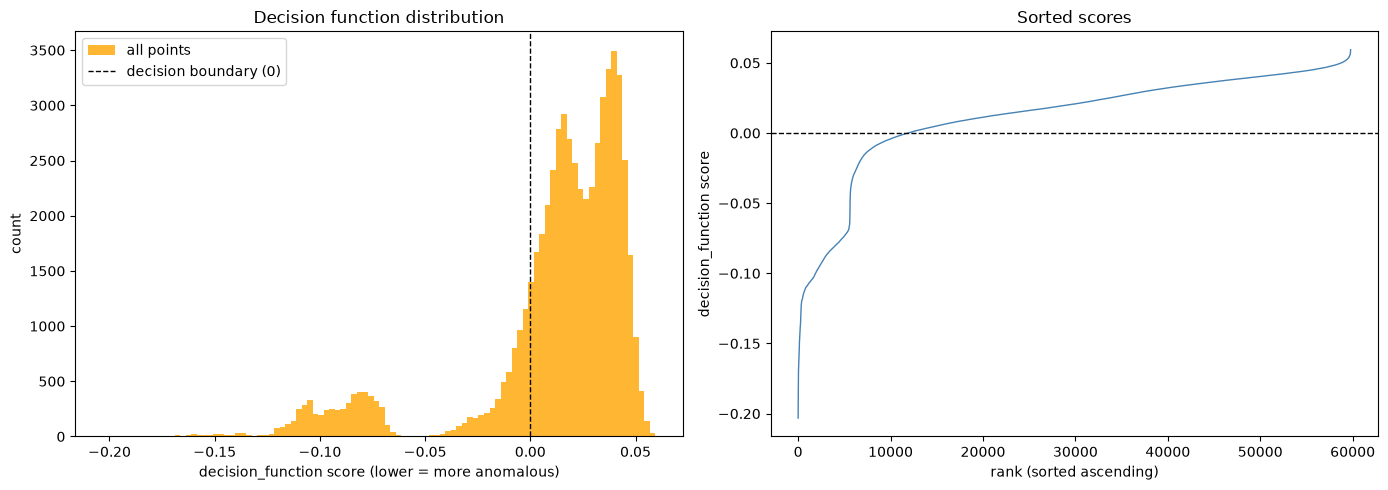

n points               : 59779
score min / max         : -0.2032 / 0.0594
score mean / std        : 0.0115 / 0.0385
   0.1th percentile     : -0.1636  (59 points below)
   0.5th percentile     : -0.1287  (298 points below)
     1th percentile     : -0.1143  (597 points below)
     2th percentile     : -0.1068  (1195 points below)
     5th percentile     : -0.0877  (2988 points below)


array([ 0.01118203, -0.10054962, -0.01220144, ...,  0.00150036,
        0.00352807,  0.00091859], shape=(59779,))

In [15]:
from anomaly_detection.utils.score_diagnostics import run_diagnostics

run_diagnostics(system_model, X_system, known_anomaly_mask=None)

In [16]:
decision_scores = system_model.decision_function(X_system)

new_contamination = np.mean(decision_scores < 0.05)

new_contamination

np.float64(0.983054249820171)

In [17]:
anomalies_df = results_df[results_df['prediction'] == -1]

anomalies_df

,month_cos,second_cos,day_sin,month_sin,second_sin,hour_sin,hour_cos,minute_sin,minute_cos,deltatime,...,status,new_value,context,session_id,process_name,entity,old_value,actor,anomaly_score,prediction
1,6.123234e-17,2.079117e-01,-0.433884,1.000000e+00,-0.978148,0.866025,0.500000,-0.207912,0.978148,0 days 00:00:00.031244,...,None,Démarrage automatique,None,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage à la demande,NaN,-0.600550,-1
2,6.123234e-17,2.079117e-01,-0.433884,1.000000e+00,-0.978148,0.866025,0.500000,-0.207912,0.978148,0 days 00:00:00.328128,...,en cours d’exécution,None,None,NaN,NaN,Carte de performance WMI,None,NaN,-0.512201,-1
4,6.123234e-17,3.090170e-01,-0.433884,1.000000e+00,-0.951057,0.965926,0.258819,0.207912,0.978148,0 days 00:02:00.011128,...,None,Démarrage à la demande,None,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage automatique,NaN,-0.601647,-1
5,6.123234e-17,3.090170e-01,-0.433884,1.000000e+00,-0.951057,0.965926,0.258819,0.207912,0.978148,0 days 00:00:00.031255,...,arrêté,None,None,NaN,NaN,Service de transfert intelligent en arrière-plan,None,NaN,-0.507492,-1
6,6.123234e-17,9.781476e-01,-0.433884,1.000000e+00,0.207912,0.965926,0.258819,0.866025,0.500000,0 days 00:07:14.224809,...,en cours d’exécution,None,None,NaN,NaN,Service de licences de client (ClipSVC),None,NaN,-0.510600,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59770,-1.000000e+00,-5.877853e-01,0.974928,1.224647e-16,-0.809017,0.707107,-0.707107,-0.951057,0.309017,0 days 00:00:00.171883,...,arrêté,None,None,NaN,NaN,Service d'inscription de la gestion des périph...,None,NaN,-0.502178,-1
59772,-1.000000e+00,-3.090170e-01,0.974928,1.224647e-16,-0.951057,0.707107,-0.707107,-0.951057,0.309017,0 days 00:00:01.671864,...,en cours d’exécution,None,None,NaN,NaN,Service de déploiement AppX (AppXSVC),None,NaN,-0.500984,-1
59773,-1.000000e+00,-1.045285e-01,0.974928,1.224647e-16,-0.994522,0.707107,-0.707107,-0.951057,0.309017,0 days 00:00:02.583376,...,None,None,3,NaN,NaN,\??\C:\Users\Administrateur.CARTE\AppData\Loca...,None,NaN,-0.624763,-1
59774,-1.000000e+00,-1.836970e-16,0.974928,1.224647e-16,-1.000000,0.707107,-0.707107,-0.951057,0.309017,0 days 00:00:00.180806,...,None,None,34,NaN,NaN,\??\C:\Users\Administrateur.CARTE\AppData\Loca...,None,NaN,-0.651632,-1


In [18]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(anomalies_df['event_id'].value_counts())

event_id
7036     6255
7040     4637
6013      167
16        152
1801       72
55         72
6          61
1          35
15         32
12         21
35         20
98         18
6033       17
20         12
2          12
7001       11
14         10
7002       10
13          9
44          8
43          7
19          7
7045        6
1074        6
6006        6
50104       6
50105       6
50106       6
51047       6
51057       6
50037       6
109         6
153         6
25          6
27          6
18          6
32          6
30          6
172         6
3           6
11          6
16962       6
16977       6
16983       6
16993       6
50036       6
50103       6
51046       6
6009        6
6005        6
10148       6
7026        6
6038        6
1054        6
8015        6
5823        4
1014        4
7042        3
7023        3
10149       3
7024        2
7034        2
15008       1
15007       1
10010       1
36          1
8021        1
8032        1
Name: count, dtype: int64


In [19]:
# Extract samples from each anomalous event ID
def pick_system_samples(n_samples_per_event):
    for event_id, group in anomalies_df.groupby("event_id"):
        print(f"\n{'=' * 60}")
        print(f"EventID {event_id}  --  {len(group)} anomalous rows")
 
        idx_min, idx_max = group.index.min(), group.index.max()
        idx_span = idx_max - idx_min
        print(f"row-index range: {idx_min} -> {idx_max}  (span: {idx_span})")
        print(f"{'=' * 60}")
 
        sample = group.sort_values("anomaly_score").head(n_samples_per_event)
 
        for idx, row in sample.iterrows():
            print(f"\n  row index:        {idx}")
            print(f"  event_record_id:  {row['event_record_id']}")
            print(f"  anomaly_score:    {row['anomaly_score']:.4f}")
 
            for col in [
                "event_id",
                "previous_event_id",
                "event_id_frequency",
                "version",
                "correlation_activity_id",
                "execution_thread_id",
            ]:
                if col in row and pd.notna(row[col]):
                    val = str(row[col])[:300]
                    print(f"  {col:<16}: {val}")
            
            for col in [
                "actor",
                "process_name",
                "session_id",
                "status",
                "old_value",
                "new_value",
                "entity",
                "context",
            ]:
                if col in row and pd.notna(row[col]):
                    val = str(row[col])[:300]
                    print(f"  {col:<16}: {val}")

In [20]:
from contextlib import redirect_stdout

with open(output_path / 'anomalous_samples.txt', 'w') as f:
    with redirect_stdout(f):
        pick_system_samples(5)

In [21]:
import joblib

joblib.dump(system_model, model_path / "system_model.joblib")

['c:\\Users\\hp\\Documents\\School\\anomaly-detection\\src\\anomaly_detection\\models\\system_model.joblib']